# Visualizations

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import time as t

# sparse matrix
from scipy.sparse import csc_array, csr_array

# this will handle the supported file formats
from imzy import get_reader

In [3]:
# File paths to .d folder
two_week_path = r"Y:\spraggins\sandbox\spathij\spinal cord injury round 1\spinal cord injury 3\2week_3.9_neg\2week_3.9_neg.d"
four_week_path = r"Y:\spraggins\sandbox\spathij\spinal cord injury round 1\spinal cord injury 3\4week_3.9_neg\4week_3.9_neg.d"

# Give path to reader
path = Path(four_week_path)
reader = get_reader(path)
print(reader)

### Spinal Cord TIC Image

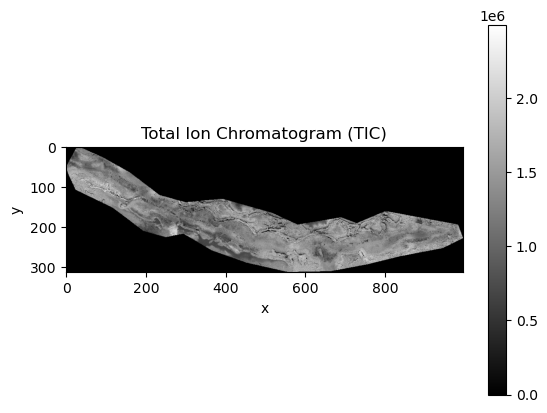

In [4]:
# get TIC array - TIC is returned as a 1D array
tic = reader.get_tic()
# convert the 1d array to 2d for visualization
tic2d = reader.reshape(tic)

# This is what our zebrafish spinal cord looks like
fig, ax = plt.subplots()
im = ax.imshow(tic2d, cmap="gray")
ax.set(title="Total Ion Chromatogram (TIC)", xlabel="x", ylabel="y")
plt.colorbar(im)
#plt.savefig('spinal_cord_tic.png', dpi=300, bbox_inches='tight')

In [25]:
# Good candidate for a pixel to align to
x_cond = reader.x_coordinates == 0
y_cond = reader.y_coordinates == 300

base_pixel_idx = np.where(x_cond & y_cond)[0]

In [26]:
print(base_pixel_idx)

[]


### Five Spectra Across the Spinal Cord

In [5]:
n_pixels = len(tic)
n_mz = len(reader[1][0])

#Print the shape of our data
print("We have " + str(n_pixels) + " pixels.")
print("We have " + str(n_mz) + " m/z values (columns).")

We have 109663 pixels.
We have 255681 m/z values (columns).


In [15]:
import random 

random_pixels = []
for i in range(5):
    random_pixels.append(random.randrange(0, n_pixels))

coords = []
for pix in random_pixels:
    coord = []
    coord.append(reader.x_coordinates[pix])
    coord.append(reader.y_coordinates[pix])
    coords.append(coord)

In [19]:
for i in range(5):
    print(f"Pixel {random_pixels[i]} at: " + str(coords[i]))

Pixel 49760 at: [714, 199]
Pixel 65024 at: [913, 218]
Pixel 109629 at: [632, 312]
Pixel 36486 at: [341, 181]
Pixel 60089 at: [657, 212]


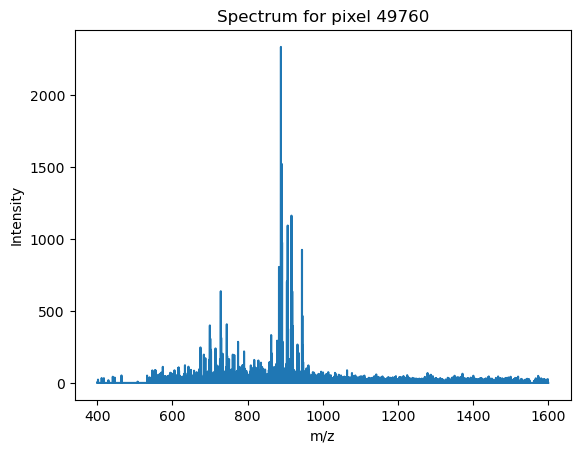

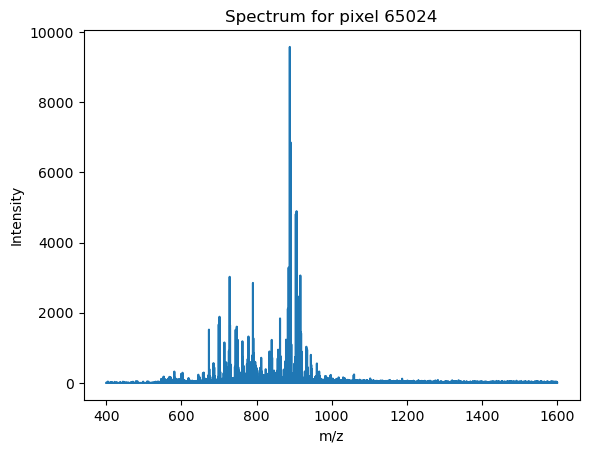

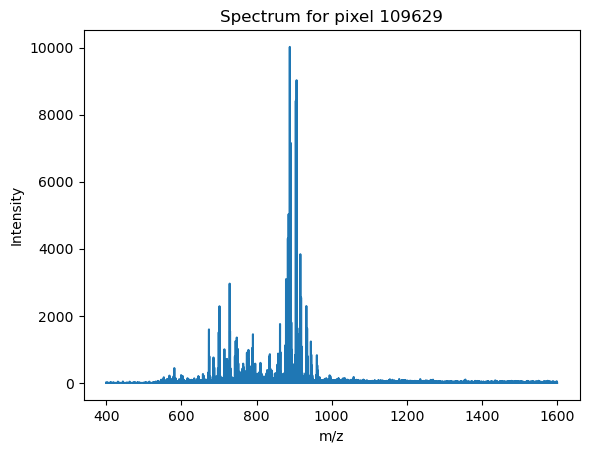

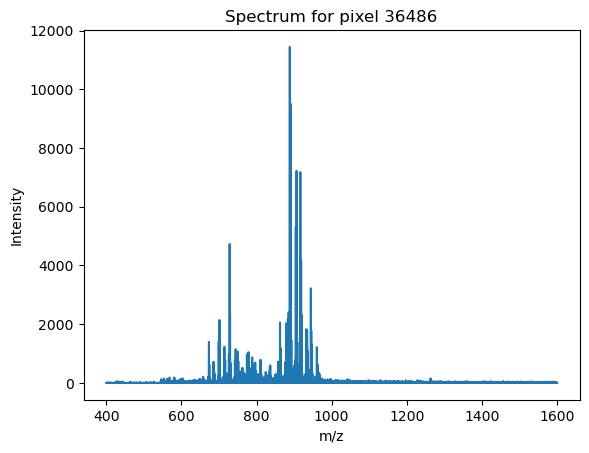

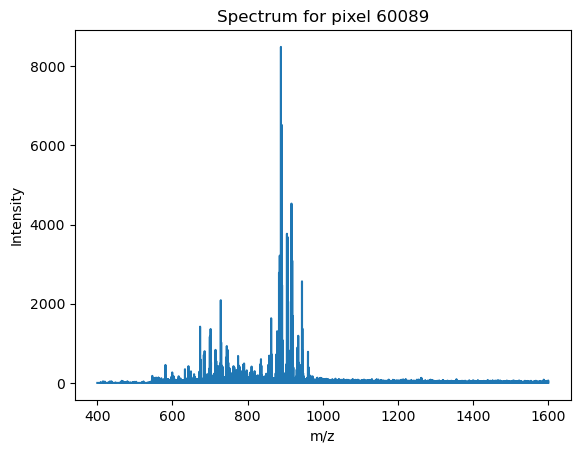

In [18]:
# Applying TIC Normalization to spectrum at pixel 0
for pix in random_pixels:
    x, y = reader.get_spectrum(pix)
    fig, ax = plt.subplots()
    ax.plot(x, y)
    _ = ax.set(xlabel="m/z", ylabel="Intensity", title=f"Spectrum for pixel {pix}")
    plt.savefig(f'pixel{pix}_spectrum.png', dpi=300, bbox_inches='tight')

### Ion Images

In [31]:
# you can use the normalization values when extracting the summed spectrum
x, y = reader.get_summed_spectrum(reader.pixels, scales=scales)
indices, _ = find_peaks(y, height=np.mean(y) + 3 * np.std(y), distance=5)
px = x[indices]
py = y[indices]

NameError: name 'scales' is not defined

In [30]:
# let's plot a couple of images, maybe random 20 in a grid of 4x5
n_images = 6
random_indices = np.random.choice(len(px), size=n_images, replace=False)
fig, axs = plt.subplots(4, 5, figsize=(15, 10))
for i, ax in enumerate(axs.flat):
    if i < n_images:
        im = ax.imshow(images_for_mzs[random_indices[i]], cmap="gray")
        ax.set(title=f"m/z = {px[random_indices[i]]:.2f}", xlabel="x", ylabel="y")
        plt.colorbar(im, ax=ax)
        plt.savefig(f'pixel{pix}_spectrum.png', dpi=300, bbox_inches='tight')
    else:
        ax.axis("off")

TypingError: Failed in nopython mode pipeline (step: nopython frontend)
[1m[1m[1mFailed in nopython mode pipeline (step: nopython frontend)
[1m[1m[1mNo implementation of function Function(<built-in function mul>) found for signature:
 
 >>> mul(reflected list(float64)<iv=None>, float64)
 
There are 14 candidate implementations:
[1m - Of which 12 did not match due to:
 Overload of function 'mul': File: <numerous>: Line N/A.
   With argument(s): '(reflected list(float64)<iv=None>, float64)':[0m
[1m  No match.[0m
[1m - Of which 2 did not match due to:
 Operator Overload in function 'mul': File: unknown: Line unknown.
   With argument(s): '(reflected list(float64)<iv=None>, float64)':[0m
[1m  No match for registered cases:
   * (int64, int64) -> int64
   * (int64, uint64) -> int64
   * (uint64, int64) -> int64
   * (uint64, uint64) -> uint64
   * (float32, float32) -> float32
   * (float64, float64) -> float64
   * (complex64, complex64) -> complex64
   * (complex128, complex1

In [ ]:
fig, ax = plt.subplots()
im = ax.imshow(image_for_mz, cmap="gray")
ax.set(title=f"Ion Image for m/z = {mz:.2f}", xlabel="x", ylabel="y")
plt.colorbar(im)
plt.savefig(f'Ion Image for m/z {mz:.2f}.png', dpi=300, bbox_inches='tight')